# 第062讲 可复现实验
先阅读lab.pdf。所有输出来自本目录固定数据；运行不会覆盖冻结结果。

In [1]:
from pathlib import Path
import json
import numpy as np
from common import load_data
data = load_data()
print({k: len(v["id"]) for k,v in data.items()})

{'train': 160, 'validation': 100, 'test': 220}


## 两种损失的手算核验
回归报告半MSE，分类原始分数是完整logit。

In [2]:
from gbdt import GBDT,negative_gradient,loss
X = np.arange(1,5).reshape(-1,1)
for kind,y in [("squared",np.array([1.,1.,3.,3.])),("logistic",np.array([0.,0.,1.,1.]))]:
    model = GBDT(kind,2,.5,1,1).fit(X,y)
    print(kind,model.losses_)
    for h in model.history_: print({k:h[k] for k in ["round","pseudo_residual","leaf_values","score"]})

squared [0.5, 0.125, 0.03125]
{'round': 1, 'pseudo_residual': [-1.0, -1.0, 1.0, 1.0], 'leaf_values': [-1.0, 1.0], 'score': [1.5, 1.5, 2.5, 2.5]}
{'round': 2, 'pseudo_residual': [-0.5, -0.5, 0.5, 0.5], 'leaf_values': [-0.5, 0.5], 'score': [1.25, 1.25, 2.75, 2.75]}
logistic [0.6931471805599453, 0.3132616875182228, 0.17028369083440628]
{'round': 1, 'pseudo_residual': [-0.5, -0.5, 0.5, 0.5], 'leaf_values': [-2.0, 2.0], 'score': [-1.0, -1.0, 1.0, 1.0]}
{'round': 2, 'pseudo_residual': [-0.2689414213699951, -0.2689414213699951, 0.2689414213699951, 0.2689414213699951], 'leaf_values': [-1.3678794411714423, 1.3678794411714423], 'score': [-1.6839397205857212, -1.6839397205857212, 1.6839397205857212, 1.6839397205857212]}


In [3]:
labels = np.array([0.,0.,1.,1.])
first_order = GBDT("logistic",1,.5,1,1,logistic_update="gradient").fit(X,labels)
newton = GBDT("logistic",1,.5,1,1,logistic_update="newton").fit(X,labels)
print("gradient logit",first_order.decision_function(X))
print("Newton logit",newton.decision_function(X))

gradient logit [-0.25 -0.25  0.25  0.25]
Newton logit [-1. -1.  1.  1.]


In [4]:
from gbdt import sigmoid
y = np.array([0.,0.,1.,1.]); F = np.array([-.7,.2,1.1,-1.3]); h = 1e-5
numerical=[]
for i in range(4):
    plus=F.copy(); minus=F.copy(); plus[i]+=h; minus[i]-=h
    numerical.append(-4*(loss(y,plus,"logistic")-loss(y,minus,"logistic"))/(2*h))
print("analytic",negative_gradient(y,F,"logistic"))
print("finite difference",numerical)

analytic [-0.33181223 -0.549834    0.24973989  0.78583498]
finite difference [-0.33181222782729947, -0.5498339973097899, 0.24973989440901787, 0.7858349830414112]


## 冻结配置的完整实验
测试集只用于报告，配置不会根据测试结果改变。

In [5]:
from experiment import run
report = run()
print(json.dumps({k:v["metrics"] for k,v in report["results"].items()},ensure_ascii=False,indent=2))

{
  "squared": {
    "train": {
      "from_zero_loss": 0.08939286630412765,
      "sklearn_loss": 0.08939286630412765,
      "max_raw_score_difference": 2.220446049250313e-16
    },
    "validation": {
      "from_zero_loss": 0.08208994961011994,
      "sklearn_loss": 0.08208994961011994,
      "max_raw_score_difference": 2.220446049250313e-16
    },
    "test": {
      "from_zero_loss": 0.10043086885232791,
      "sklearn_loss": 0.10043086885232791,
      "max_raw_score_difference": 2.220446049250313e-16
    }
  },
  "logistic": {
    "train": {
      "from_zero_loss": 0.37634774021396444,
      "sklearn_loss": 0.3763477402139645,
      "max_raw_score_difference": 2.220446049250313e-16,
      "accuracy": 0.85
    },
    "validation": {
      "from_zero_loss": 0.4706652842263324,
      "sklearn_loss": 0.4706652842263324,
      "max_raw_score_difference": 2.220446049250313e-16,
      "accuracy": 0.79
    },
    "test": {
      "from_zero_loss": 0.4714541676158369,
      "sklearn_loss":

In [6]:
for kind in ["squared","logistic"]:
    r=report["results"][kind]
    print(kind,"max stage difference",r["max_stage_difference"],"maximum loss increment",np.max(np.diff(r["training_loss"])))

squared max stage difference 2.220446049250313e-16 maximum loss increment -0.0019403548042682545
logistic max stage difference 4.440892098500626e-16 maximum loss increment -0.00047832678020964803


In [7]:
import subprocess,sys
command=[sys.executable,"test_experiment.py","--out","outputs/notebook-tests.json"]
completed=subprocess.run(command,check=True,capture_output=True,text=True)
result=json.loads(completed.stdout)
print(result["status"],result["check_count"])

passed 120


## 图的阅读
图为同一冻结实验生成；图题与解释见lecture.pdf和lab.pdf。

01_loss_derivatives.png


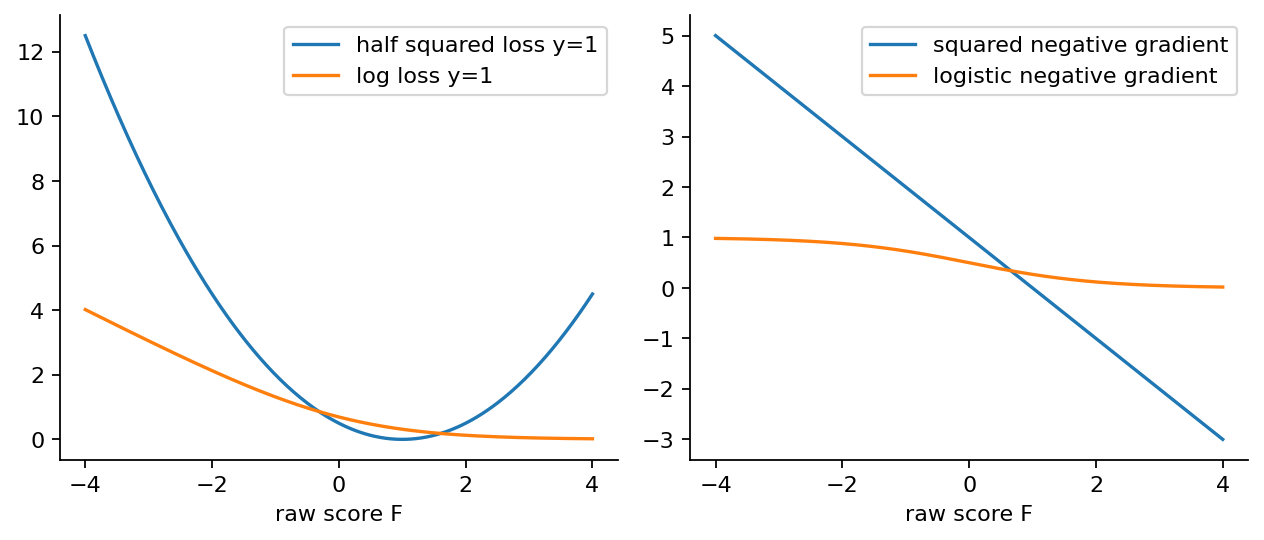

02_hand_rounds.png


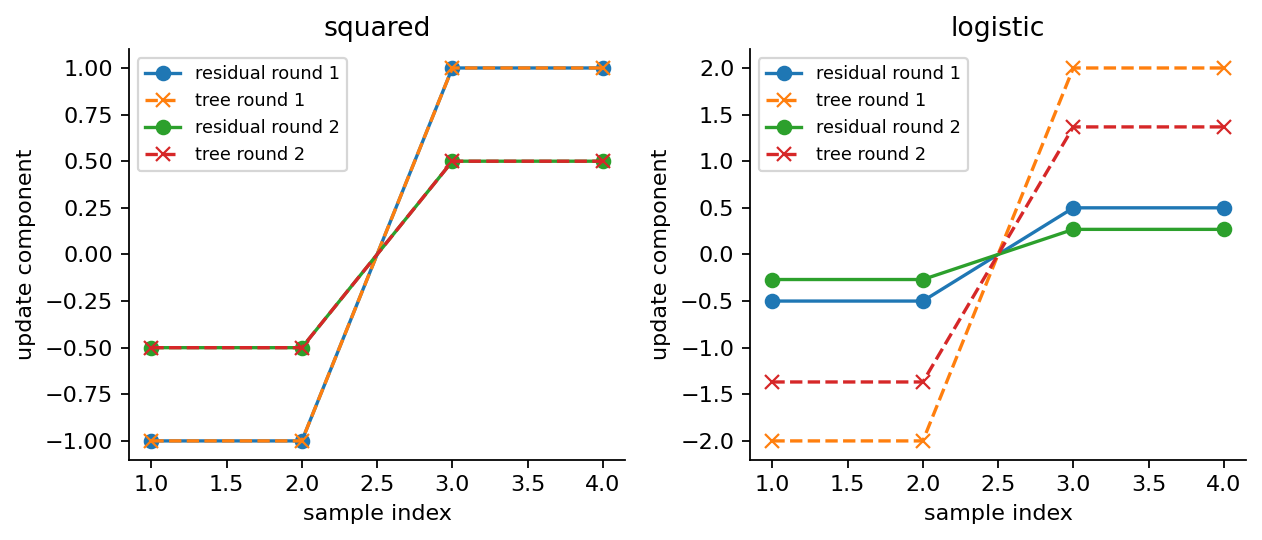

03_additive_regression.png


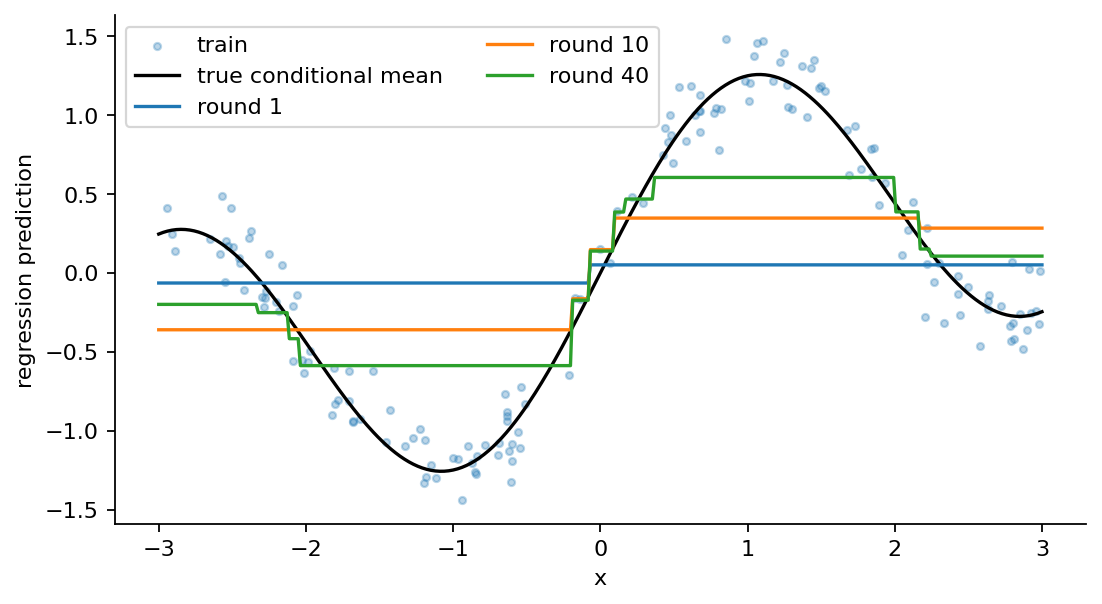

04_loss_curves.png


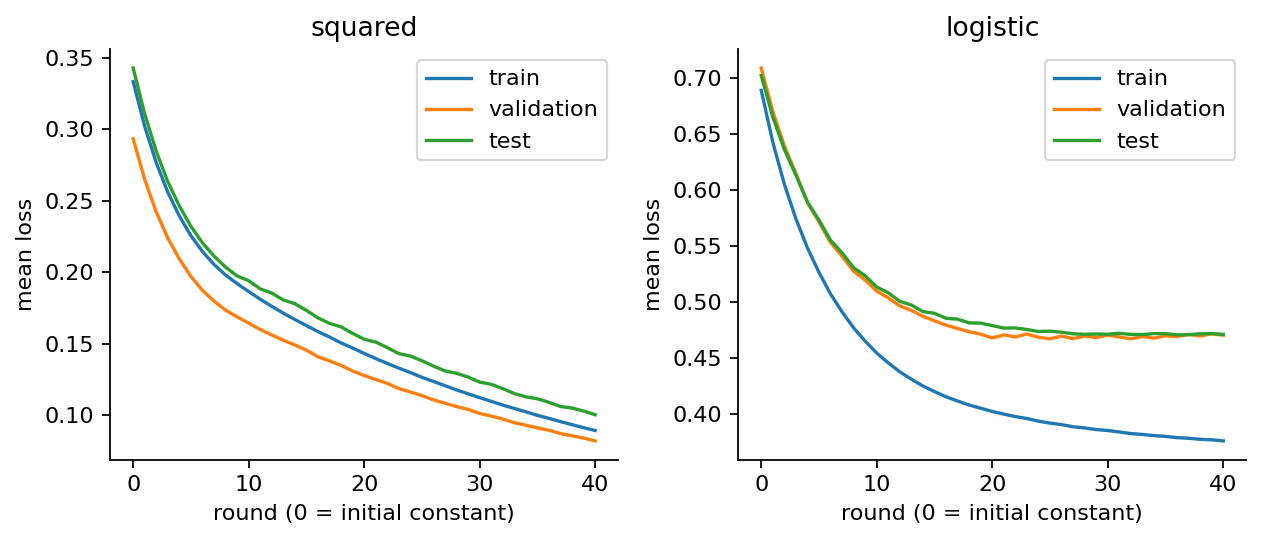

05_logit_probability.png


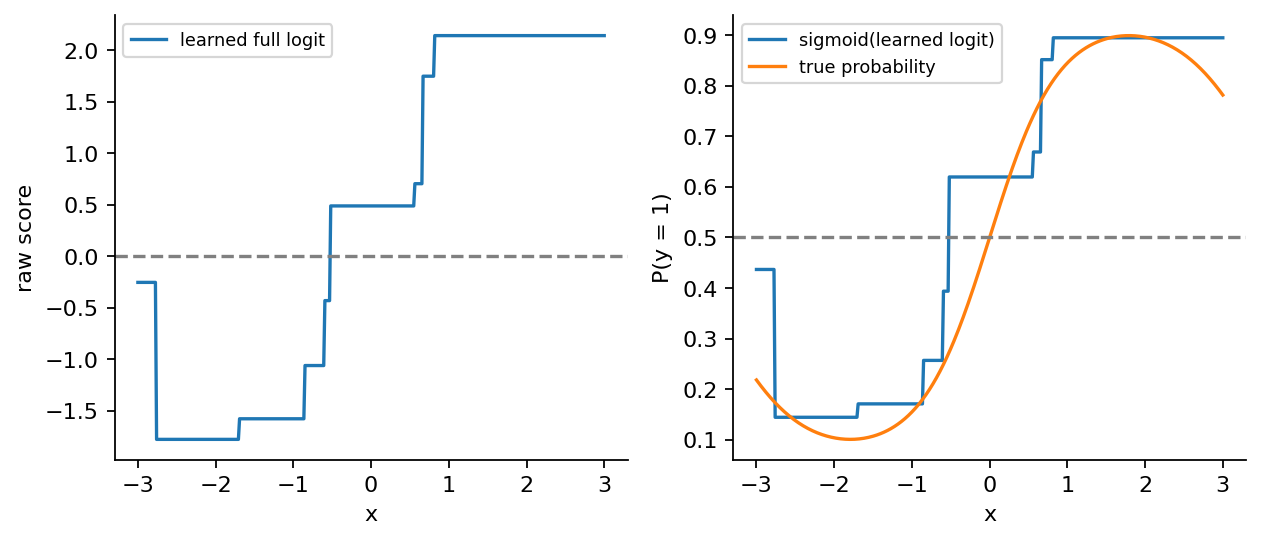

06_learning_rate.png


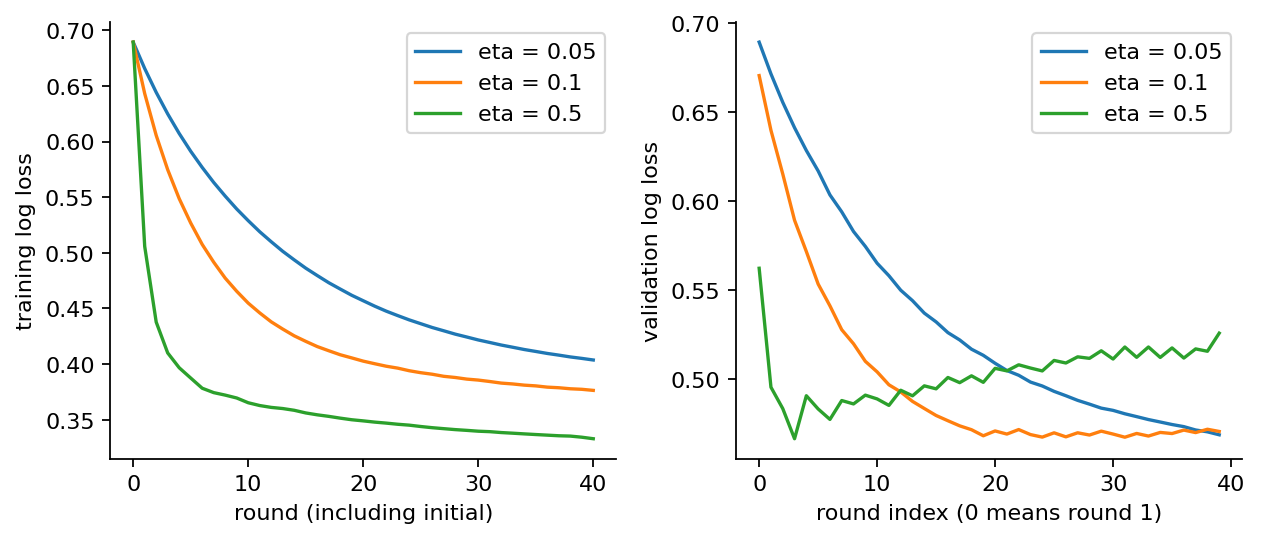

In [8]:
from IPython.display import display,Image
for name in sorted(Path("figures").glob("*.png")):
    print(name.name)
    display(Image(filename=str(name),width=650))